In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
weather = pd.read_csv("weather.csv")

In [3]:
weather.head()

,Date,Temperature,Rainfall,Wind,Humidity,Pressure
0,1/1/2018,24.3,0.0,20,68,1019.7
1,1/2/2018,26.9,3.6,17,80,1012.4
2,1/3/2018,23.4,3.6,6,82,1009.5
3,1/4/2018,15.5,39.8,24,62,1005.5
4,1/5/2018,16.1,2.8,28,68,1018.3


In [5]:
weather.dtypes

Date            object
Temperature    float64
Rainfall       float64
Wind             int64
Humidity         int64
Pressure       float64
dtype: object

In [4]:
## Renaming the columns approprietely

weather_pro = weather.rename(columns= {"Date": "ds", "Temperature": "y"})
weather_pro.head()

,ds,y,Rainfall,Wind,Humidity,Pressure
0,1/1/2018,24.3,0.0,20,68,1019.7
1,1/2/2018,26.9,3.6,17,80,1012.4
2,1/3/2018,23.4,3.6,6,82,1009.5
3,1/4/2018,15.5,39.8,24,62,1005.5
4,1/5/2018,16.1,2.8,28,68,1018.3


In [5]:
weather_pro['ds'] = pd.to_datetime(weather_pro['ds'])

In [6]:
weather_pro.head()

,ds,y,Rainfall,Wind,Humidity,Pressure
0,2018-01-01,24.3,0.0,20,68,1019.7
1,2018-01-02,26.9,3.6,17,80,1012.4
2,2018-01-03,23.4,3.6,6,82,1009.5
3,2018-01-04,15.5,39.8,24,62,1005.5
4,2018-01-05,16.1,2.8,28,68,1018.3


In [7]:
weather_pro.dtypes

ds          datetime64[ns]
y                  float64
Rainfall           float64
Wind                 int64
Humidity             int64
Pressure           float64
dtype: object

In [8]:
## Initializing the Prophet by adding more regressors
model = Prophet()

model.add_regressor('Humidity')
model.add_regressor('Pressure')
model.add_regressor('Rainfall')
model.add_regressor('Wind')

In [9]:
split_index = int(len(weather_pro) * 0.8)

In [10]:
train_df = weather_pro.iloc[:split_index]
test_df = weather_pro.iloc[split_index:]

In [11]:
train_df

,ds,y,Rainfall,Wind,Humidity,Pressure
0,2018-01-01,24.3,0.0,20,68,1019.7
1,2018-01-02,26.9,3.6,17,80,1012.4
2,2018-01-03,23.4,3.6,6,82,1009.5
3,2018-01-04,15.5,39.8,24,62,1005.5
4,2018-01-05,16.1,2.8,28,68,1018.3
...,...,...,...,...,...,...
287,2018-10-15,10.7,0.0,39,59,1022.2
288,2018-10-16,14.7,0.0,33,54,1014.7
289,2018-10-17,14.2,0.0,28,52,1012.7
290,2018-10-18,11.6,0.0,17,59,1023.3


In [12]:
model.fit(train_df)

16:00:49 - cmdstanpy - INFO - Chain [1] start processing
16:00:49 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
forecast = model.predict(test_df)

In [14]:
test_df["yhat"] = forecast["yhat"].values

C:\Users\Blossom Academy\AppData\Local\Temp\ipykernel_23412\3255398763.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["yhat"] = forecast["yhat"].values


In [15]:
mae = mean_absolute_error(test_df["y"], test_df["yhat"])
rmse = np.sqrt(mean_squared_error(test_df["y"], test_df["yhat"]))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 11.717116081274792
RMSE: 13.253770612570788


#### Build another model for prediction, this case the model won't be trained 
#### with the exogeneous factors

13:46:21 - cmdstanpy - INFO - Chain [1] start processing
13:46:21 - cmdstanpy - INFO - Chain [1] done processing


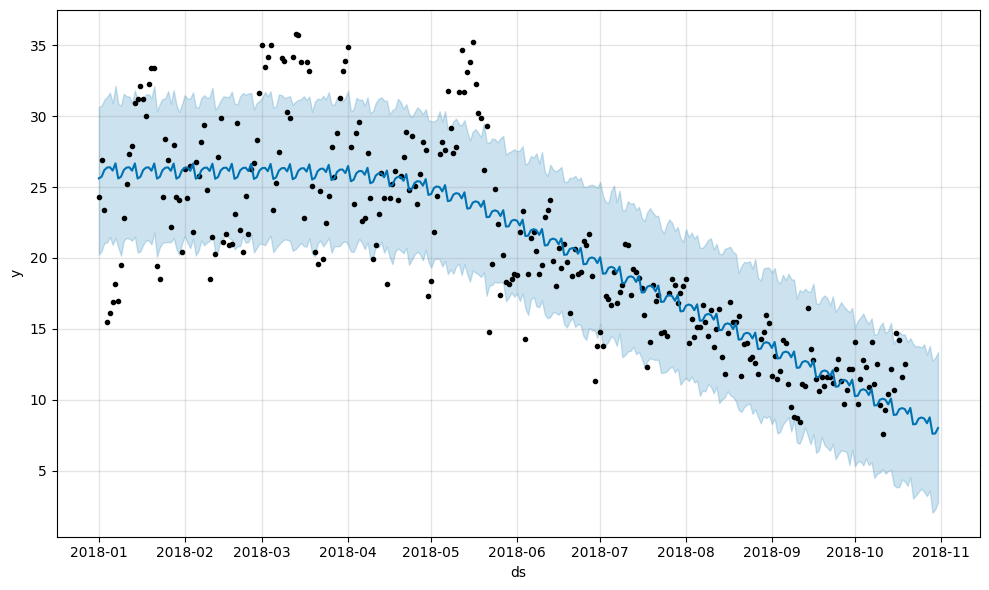

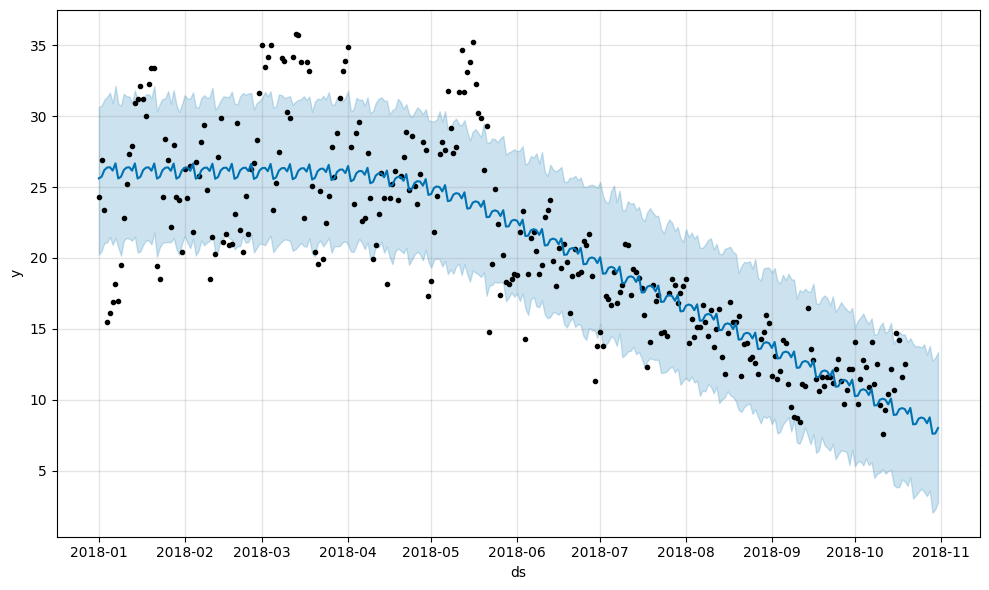

In [32]:
model_simple = Prophet()

model_simple.fit(train_df[['ds', 'y']])

future = model_simple.make_future_dataframe(periods=12)

forecast_future = model_simple.predict(future)

model_simple.plot(forecast_future)